# Encuesta Clima de los Negocios

In [80]:
# =============================================================================
# 0. CONFIGURACIÓN
# =============================================================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42

DATA_DIR = './datos_limpios'
corredores = pd.read_csv(f'{DATA_DIR}/ECN_unified.csv')

# Ajustamos variables

In [81]:
# Convertir situacion_economica en dummy: 1 y 2 → 0, 3 → 1
corredores['situacion_econ_empeorara'] = (corredores['situacion_economica'] == 3).astype(int)
corredores = corredores.drop(columns=['situacion_economica'])

# Convertir seguridad_aumento en dummy: 1 y 2 → 0, 3 → 1
corredores['inseguridad_aumento'] = (corredores['seguridad_aumento'] == 3).astype(int)
corredores = corredores.drop(columns=['seguridad_aumento'])

# Convertir percepcion_seguridad en dummy: 1 y 3 → 0, 2 → 1
corredores['bogota_insegura'] = (corredores['percepcion_seguridad'] == 2).astype(int)
corredores = corredores.drop(columns=['percepcion_seguridad'])

# Promedio de percepción de inseguridad
corredores['percepcion_inseguridad'] = (corredores['inseguridad_aumento'] + corredores['bogota_insegura']) / 2
corredores = corredores.drop(columns=['inseguridad_aumento', 'bogota_insegura'])

# Convertir year en dummy: 2024 → 1, 2023 → 0
corredores['anio_2024'] = (corredores['year'] == 2024).astype(int)
corredores = corredores.drop(columns=['year'])

# Eliminar variable mercado y filas donde tamano == 4
corredores = corredores.drop(columns=['mercado', 'cargo', 'victima', 'BD_MATRICULA','denuncio'])
corredores = corredores[corredores['tamano'] != 4]

# Copia del df para K-Means
df_clustering = corredores.copy()
df_clustering = df_clustering.drop(columns=['extorsion', 'ataq_infraestruc', 'secuestro', 'hurto', 'informatico',
                                            'vandalismo', 'fraude', 'estafa', 'hurto_maq', 'ninguna', 'anio_2024']) 

# Guardar variables categóricas para comparar con la segmentación después
meta = df_clustering[['sector_economico', 'tamano']].copy()
df_clustering = df_clustering.drop(columns=['sector_economico', 'tamano'])

# Promediar variables de distrito y nacionales para necesidades del empresario
pairs = [
    ('inv_extranjera',    'dis_inv_extranjera'),
    ('Stem',              'dis_Stem'),
    ('simp_tramites',     'dis_simp_tramites'),
    ('gob_recurso_humano','dis_recurso_humano'),
    ('func_empresas',     'dis_func_empresas'),
    ('sistema_salud',     'dis_sistema_salud'),
    ('acceso_finan',      'dis_acceso_finan'),
    ('gob_seguridad',     'dis_seguridad'),
    ('inno_emprend',      'dis_inno_emprend'),
    ('ayuda_empresas',    'dis_ayuda_empresas'),
    ('mitig_crisis_int',  'dis_mitig_crisis_int'),
    ('fintech',           'dis_fintech'),
]

for var, dis_var in pairs:
    df_clustering[var] = (df_clustering[var] + df_clustering[dis_var]) / 2
    df_clustering = df_clustering.drop(columns=[dis_var])

df_clustering

,impacto_internacional,entorno_inversion,capacidad_compra,crecimiento_econ,infraestructura,conectividad,facil_crear_emp,recurso_humano,estab_jurid,seguridad,promg_forta_emp,reg_mercado_lab,servicios_pub,produc_finan,facil_comex,impuestos,inv_extranjera,Stem,simp_tramites,gob_recurso_humano,func_empresas,sistema_salud,acceso_finan,gob_seguridad,inno_emprend,ayuda_empresas,mitig_crisis_int,fintech,inst_alarm,inst_cam_vig,letreros_disuasivos,seguridad_priv,refor_puer_ven,art_autoridades,cap_per_estrg_prev,perd_clientes,perd_produc_trab,daños_establ,imp_salud_fis_mental,desin_inver,daño_reputacional,pago_seg_priv,no_gen_cost,situacion_econ_empeorara,percepcion_inseguridad
0,5,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0.5
1,3,3,2,3,3,3,1,3,3,3,2,3,3,2,2,2,0.0,1.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,1.0,0.5,0.0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1.0
2,3,4,4,4,4,4,4,5,4,4,5,4,4,3,4,3,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,1.0,0.0,0.0,0.5,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0.0
3,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0.5,0.5,0.5,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.5,0.0,1,1,1,0,1,0,0,1,1,0,0,1,1,0,0,0,0.5
5,3,3,3,3,3,3,2,2,3,2,2,3,2,3,2,2,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.5,1.0,0.0,0.0,0.5,1,1,1,1,1,1,1,1,0,0,1,0,0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4243,2,1,2,1,2,3,2,4,1,1,2,1,4,4,2,1,0.5,0.5,0.0,0.0,0.5,0.0,0.0,0.5,0.0,1.0,0.0,0.0,1,1,0,1,0,0,0,1,1,1,1,1,1,1,1,1,1.0
4244,2,3,1,1,5,5,5,5,5,1,5,1,5,3,3,1,0.5,0.0,0.5,0.0,0.5,0.0,0.5,0.5,0.0,0.0,0.0,0.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1.0
4245,2,3,3,3,1,5,5,5,3,3,3,3,5,5,4,5,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0,1,0,1,0,0,0,0,1,1,1,0,0,0,0,0,0.5
4246,4,4,5,3,1,3,5,3,3,1,3,3,3,3,3,4,0.5,0.0,0.0,0.5,0.0,0.5,0.5,0.5,0.0,0.0,0.5,0.0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0.0


# PCA

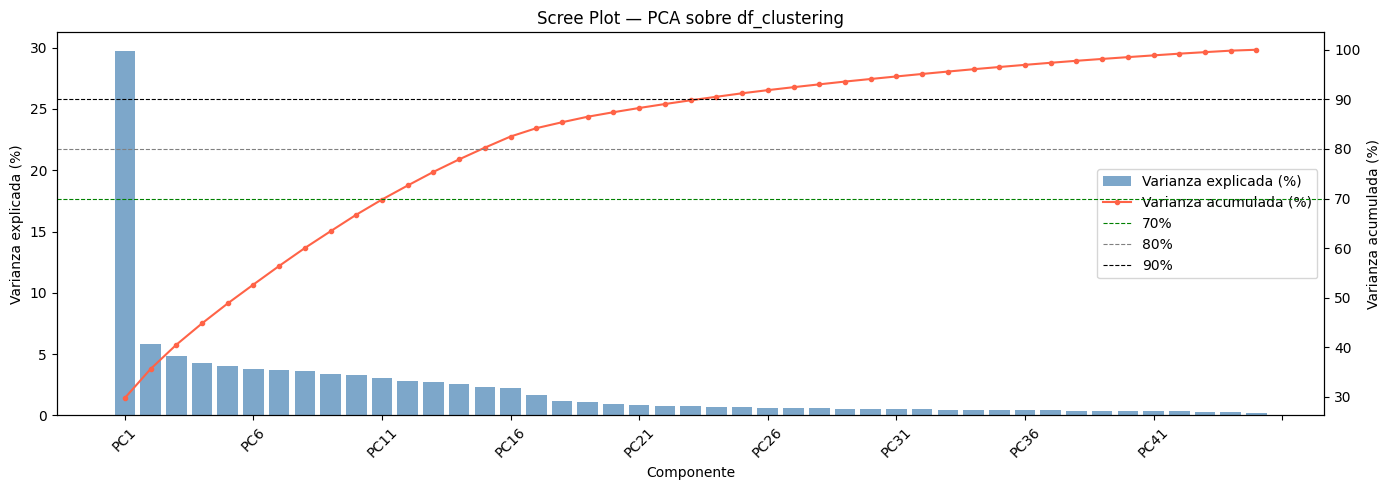

Componentes para 70% de varianza: 12
Componentes para 80% de varianza: 15
Componentes para 90% de varianza: 24
Varianza explicada por los primeros 10 componentes: 66.73%


In [82]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# PCA con todas las componentes
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(df_clustering)

var_exp    = pca_full.explained_variance_ratio_
cum_var    = np.cumsum(var_exp)
comp_labels = [f"PC{i+1}" for i in range(len(var_exp))]

# Scree plot
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(comp_labels, var_exp * 100, color='steelblue', alpha=0.7, label='Varianza explicada (%)')
ax1.set_ylabel('Varianza explicada (%)')
ax1.set_xlabel('Componente')
ax1.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(comp_labels, cum_var * 100, color='tomato', marker='o', markersize=3, label='Varianza acumulada (%)')
ax2.set_ylabel('Varianza acumulada (%)')
ax2.axhline(70, color='green',  linestyle='--', linewidth=0.8, label='70%')
ax2.axhline(80, color='gray',   linestyle='--', linewidth=0.8, label='80%')
ax2.axhline(90, color='black',  linestyle='--', linewidth=0.8, label='90%')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title('Scree Plot — PCA sobre df_clustering')
plt.tight_layout()
plt.show()

# Número de componentes para 70%, 80% y 90% de varianza
n_70 = int(np.argmax(cum_var >= 0.70)) + 1
n_80 = int(np.argmax(cum_var >= 0.80)) + 1
n_90 = int(np.argmax(cum_var >= 0.90)) + 1
print(f"Componentes para 70% de varianza: {n_70}")
print(f"Componentes para 80% de varianza: {n_80}")
print(f"Componentes para 90% de varianza: {n_90}")
print(f"Varianza explicada por los primeros 10 componentes: {cum_var[9]*100:.2f}%")

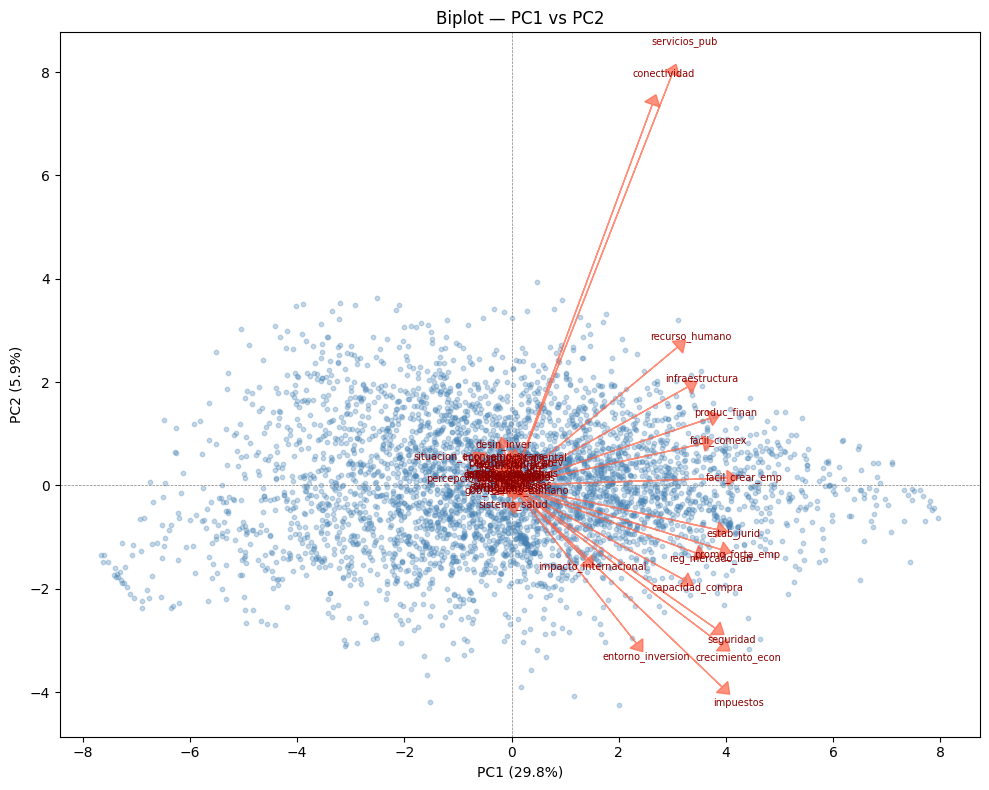

In [83]:
# Biplot PC1 vs PC2
scores      = pca_full.transform(df_clustering)
loadings    = pca_full.components_[:2].T   # shape (n_vars, 2)
feature_names = df_clustering.columns.tolist()

# Escalar scores para que quepan con las flechas
scale = np.max(np.abs(scores[:, :2])) / np.max(np.abs(loadings))

fig, ax = plt.subplots(figsize=(10, 8))

# Puntos
ax.scatter(scores[:, 0], scores[:, 1], alpha=0.3, s=10, color='steelblue')

# Flechas (loadings)
for i, var in enumerate(feature_names):
    ax.arrow(0, 0,
             loadings[i, 0] * scale, loadings[i, 1] * scale,
             head_width=0.3, head_length=0.2,
             fc='tomato', ec='tomato', alpha=0.7)
    ax.text(loadings[i, 0] * scale * 1.08,
            loadings[i, 1] * scale * 1.08,
            var, fontsize=7, ha='center', va='center', color='darkred')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax.set_title('Biplot — PC1 vs PC2')
plt.tight_layout()
plt.show()

In [84]:

# Loadings PC1 y PC2
loadings_df = pd.DataFrame(
    pca_full.components_[:2].T,
    index=df_clustering.columns,
    columns=['PC1', 'PC2']
).sort_values('PC1', key=abs, ascending=False)

print(loadings_df.to_string())

                               PC1       PC2
facil_crear_emp           0.296205  0.010379
impuestos                 0.289311 -0.287220
crecimiento_econ          0.288452 -0.226934
promg_forta_emp           0.287636 -0.091337
estab_jurid               0.282443 -0.062972
seguridad                 0.280050 -0.203683
produc_finan              0.272411  0.095667
facil_comex               0.263340  0.059622
reg_mercado_lab           0.253225 -0.096224
infraestructura           0.242079  0.140318
capacidad_compra          0.236870 -0.134446
recurso_humano            0.228008  0.196965
servicios_pub             0.220780  0.586166
conectividad              0.193501  0.542829
entorno_inversion         0.171563 -0.225206
impacto_internacional     0.102688 -0.106784
situacion_econ_empeorara -0.041896  0.037536
percepcion_inseguridad   -0.034243  0.009163
gob_seguridad            -0.015941  0.014769
perd_clientes            -0.013820 -0.003936
desin_inver              -0.010870  0.054306
func_empre

# K-Means

In [85]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Espacio PCA reducido al 70% de varianza explicada
X_pca = scores[:, :10]

# ── Selección de k sobre espacio PCA ─────────────────────────────────────────
K_RANGE = range(2, 13)
results = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca)
    results.append({
        "k":                 k,
        "inertia":           km.inertia_,
        "silhouette":        silhouette_score(X_pca, labels, sample_size=500, random_state=RANDOM_STATE),
        "davies_bouldin":    davies_bouldin_score(X_pca, labels),
        "calinski_harabasz": calinski_harabasz_score(X_pca, labels),
    })

res = pd.DataFrame(results)
print(res.round(4).to_string(index=False))

# ── K óptimo por Silhouette (mayor = mejor separación) ───────────────────────
k_opt = int(res.loc[res["silhouette"].idxmax(), "k"])
print(f"\nK óptimo (Silhouette máximo): k = {k_opt}"
      f"  →  sil = {res['silhouette'].max():.4f}"
      f"  |  db = {res.loc[res['silhouette'].idxmax(), 'davies_bouldin']:.4f}"
      f"  |  ch = {res.loc[res['silhouette'].idxmax(), 'calinski_harabasz']:.1f}")

 k    inertia  silhouette  davies_bouldin  calinski_harabasz
 2 45498.3278      0.2256          1.5443          1602.3211
 3 40335.1921      0.1532          1.8239          1172.7537
 4 38086.5004      0.1124          2.2140           910.5824
 5 36350.4616      0.1088          2.2132           765.5887
 6 35115.0489      0.1091          2.1783           663.4470
 7 34084.8663      0.0937          2.2798           590.6192
 8 33242.6376      0.0755          2.2205           534.1583
 9 32468.0871      0.0757          2.2074           490.9485
10 31796.7669      0.0765          2.2451           455.3626
11 31212.6098      0.0741          2.1872           425.2522
12 30674.4466      0.0792          2.1838           399.9784

K óptimo (Silhouette máximo): k = 2  →  sil = 0.2256  |  db = 1.5443  |  ch = 1602.3


In [86]:
from sklearn.metrics import silhouette_samples

def evaluate_clustering(X, labels, method_name):
    """Calcula métricas de clustering y retorna un dict resumen."""
    n_clusters = len(set(labels) - {-1})
    n_noise    = (labels == -1).sum()
    mask       = labels != -1
    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(X[mask], labels[mask])
    else:
        sil = np.nan
    return {
        "method":     method_name,
        "n_clusters": n_clusters,
        "n_noise":    int(n_noise),
        "silhouette": round(float(sil), 4) if not np.isnan(sil) else np.nan,
    }

# Modelo K-Means final con k_opt
km_final  = KMeans(n_clusters=k_opt, n_init=20, random_state=RANDOM_STATE)
labels_km = km_final.fit_predict(X_pca)
res_km    = evaluate_clustering(X_pca, labels_km, f"K-Means (k={k_opt})")
print(res_km)

{'method': 'K-Means (k=2)', 'n_clusters': 2, 'n_noise': 0, 'silhouette': 0.2262}


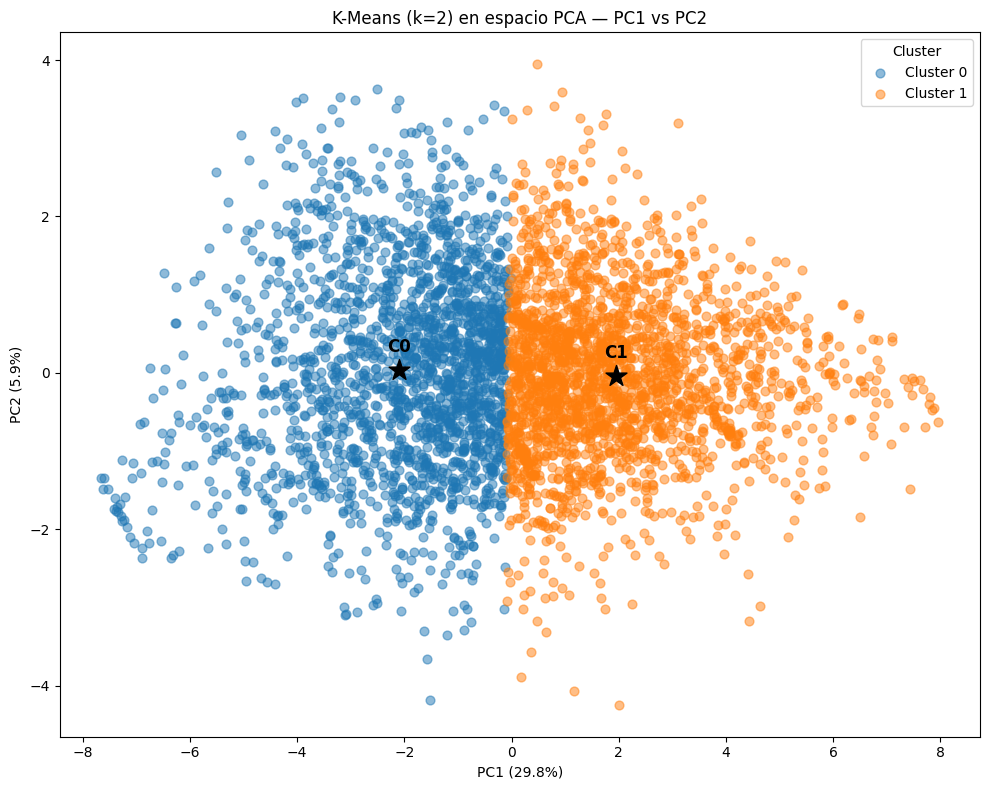

In [87]:
fig, ax = plt.subplots(figsize=(10, 8))

for seg in sorted(np.unique(labels_km)):
    mask = labels_km == seg
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               alpha=0.5, s=40, label=f"Cluster {seg}")
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    ax.scatter(cx, cy, marker="*", s=250, c="black", zorder=5)
    ax.annotate(f"C{seg}", (cx, cy), fontsize=12, fontweight="bold",
                ha="center", va="bottom", xytext=(0, 10),
                textcoords="offset points")

ax.set_xlabel(f"PC1 ({var_exp[0]:.1%})")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1%})")
ax.set_title(f"K-Means (k={k_opt}) en espacio PCA — PC1 vs PC2")
ax.legend(title="Cluster", loc="best")
plt.tight_layout()
plt.show()

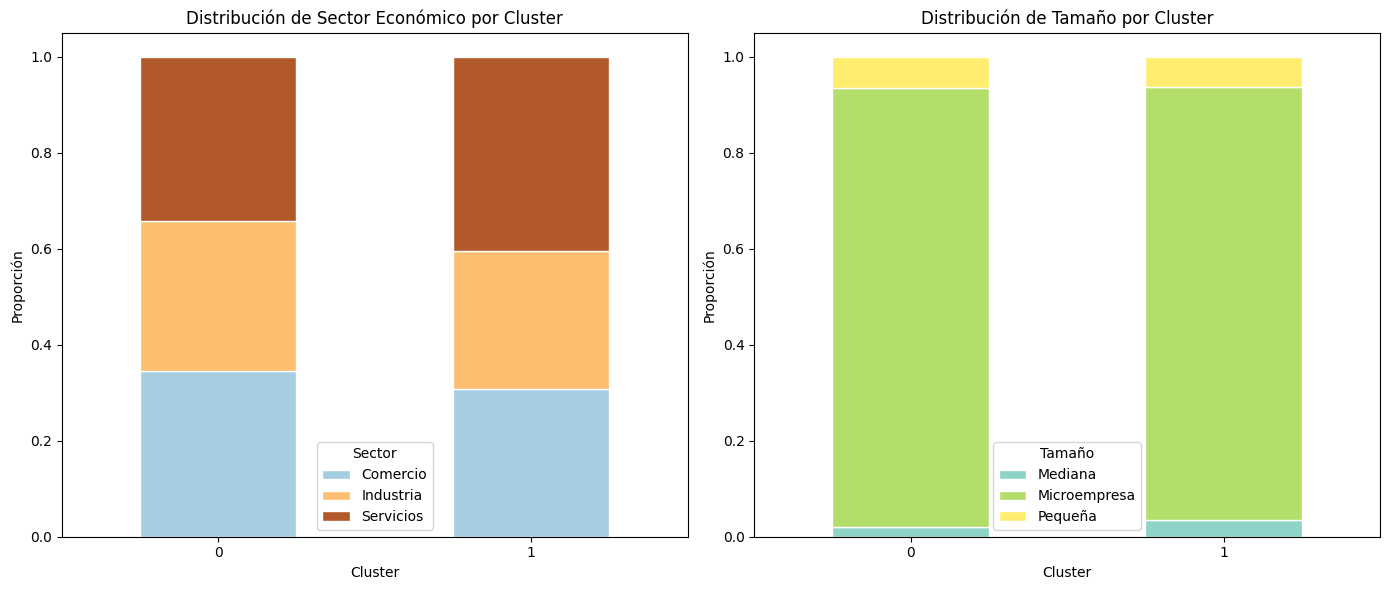

In [88]:
sector_map = {1: "Industria", 2: "Comercio", 3: "Servicios"}
tamano_map = {1: "Microempresa", 2: "Pequeña", 3: "Mediana"}

df_segmented = meta.copy()
df_segmented["Cluster"] = labels_km

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sector económico
ct_sector = pd.crosstab(
    df_segmented["Cluster"],
    df_segmented["sector_economico"].map(sector_map),
    normalize="index"
)
ct_sector.plot(kind="bar", stacked=True, ax=axes[0], colormap="Paired", edgecolor="white")
axes[0].set_title("Distribución de Sector Económico por Cluster")
axes[0].set_ylabel("Proporción")
axes[0].set_xlabel("Cluster")
axes[0].legend(title="Sector")
axes[0].tick_params(axis="x", rotation=0)

# Tamaño
ct_tamano = pd.crosstab(
    df_segmented["Cluster"],
    df_segmented["tamano"].map(tamano_map),
    normalize="index"
)
ct_tamano.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set3", edgecolor="white")
axes[1].set_title("Distribución de Tamaño por Cluster")
axes[1].set_ylabel("Proporción")
axes[1].set_xlabel("Cluster")
axes[1].legend(title="Tamaño")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

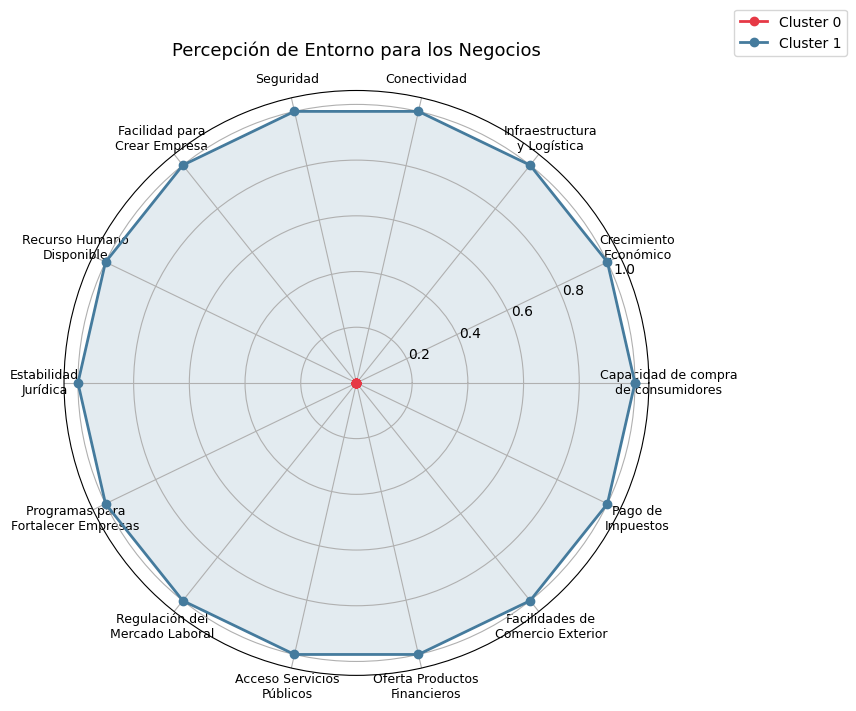

In [89]:
ENTORNO_VARS = {
    "capacidad_compra":  "Capacidad de compra\nde consumidores",
    "crecimiento_econ":  "Crecimiento\nEconómico",
    "infraestructura":   "Infraestructura\ny Logística",
    "conectividad":      "Conectividad",
    "seguridad":         "Seguridad",
    "facil_crear_emp":   "Facilidad para\nCrear Empresa",
    "recurso_humano":    "Recurso Humano\nDisponible",
    "estab_jurid":       "Estabilidad\nJurídica",
    "promg_forta_emp":   "Programas para\nFortalecer Empresas",
    "reg_mercado_lab":   "Regulación del\nMercado Laboral",
    "servicios_pub":     "Acceso Servicios\nPúblicos",
    "produc_finan":      "Oferta Productos\nFinancieros",
    "facil_comex":       "Facilidades de\nComercio Exterior",
    "impuestos":         "Pago de\nImpuestos",
}

df_radar = df_clustering.copy()
df_radar["Cluster"] = labels_km
segment_profile = df_radar.groupby("Cluster")[list(ENTORNO_VARS.keys())].mean()

# Normalizar medias a [0, 1]
profile_norm = segment_profile.copy()
for col in ENTORNO_VARS:
    mn, mx = segment_profile[col].min(), segment_profile[col].max()
    profile_norm[col] = (segment_profile[col] - mn) / (mx - mn) if mx > mn else 0.5

labels_radar = list(ENTORNO_VARS.values())
angles = np.linspace(0, 2 * np.pi, len(labels_radar), endpoint=False).tolist()
angles += angles[:1]

RADAR_COLORS = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261", "#6A4C93", "#43AA8B", "#F3722C"]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})

for idx, (seg, row) in enumerate(profile_norm.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    color = RADAR_COLORS[idx % len(RADAR_COLORS)]
    ax.plot(angles, values, "o-", linewidth=2, label=f"Cluster {seg}", color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=9)
ax.set_title("Percepción de Entorno para los Negocios", pad=25, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

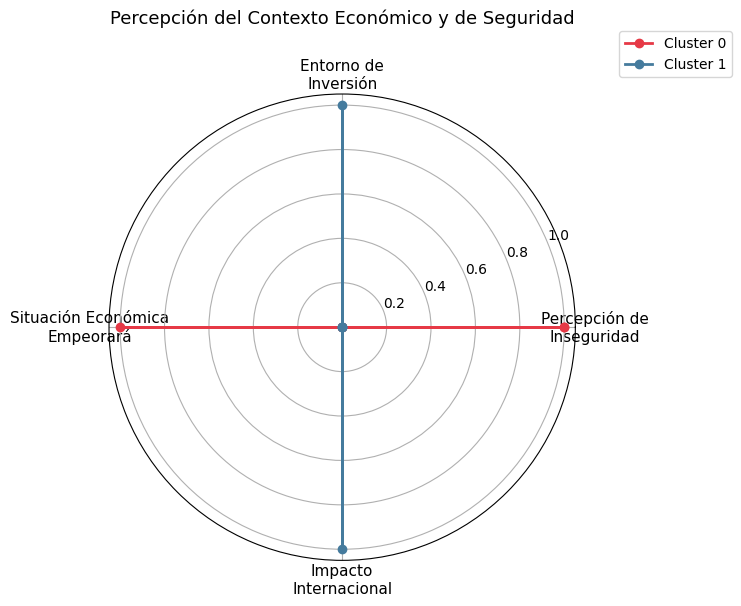

In [90]:
CONTEXTO_VARS = {
    "percepcion_inseguridad":  "Percepción de\nInseguridad",
    "entorno_inversion":       "Entorno de\nInversión",
    "situacion_econ_empeorara":"Situación Económica\nEmpeorará",
    "impacto_internacional":   "Impacto\nInternacional",
}

segment_profile_ctx = df_radar.groupby("Cluster")[list(CONTEXTO_VARS.keys())].mean()

profile_norm_ctx = segment_profile_ctx.copy()
for col in CONTEXTO_VARS:
    mn, mx = segment_profile_ctx[col].min(), segment_profile_ctx[col].max()
    profile_norm_ctx[col] = (segment_profile_ctx[col] - mn) / (mx - mn) if mx > mn else 0.5

labels_ctx = list(CONTEXTO_VARS.values())
angles_ctx = np.linspace(0, 2 * np.pi, len(labels_ctx), endpoint=False).tolist()
angles_ctx += angles_ctx[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})

for idx, (seg, row) in enumerate(profile_norm_ctx.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    color = RADAR_COLORS[idx % len(RADAR_COLORS)]
    ax.plot(angles_ctx, values, "o-", linewidth=2, label=f"Cluster {seg}", color=color)
    ax.fill(angles_ctx, values, alpha=0.15, color=color)

ax.set_xticks(angles_ctx[:-1])
ax.set_xticklabels(labels_ctx, fontsize=11)
ax.set_title("Percepción del Contexto Económico y de Seguridad", pad=25, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()